--- Initial Car Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Brand_Goodwill_Score  300 non-null    int32  
 1   Horsepower            300 non-null    int32  
 2   Mileage_kmpl          300 non-null    float64
 3   Fuel_Type             300 non-null    object 
 4   Transmission          300 non-null    object 
 5   Car_Price_USD         300 non-null    int32  
dtypes: float64(1), int32(3), object(2)
memory usage: 10.7+ KB
None

--- Missing Values Count ---
Brand_Goodwill_Score    0
Horsepower              0
Mileage_kmpl            0
Fuel_Type               0
Transmission            0
Car_Price_USD           0
dtype: int64

--- First 5 Dataset Records ---
   Brand_Goodwill_Score  Horsepower  Mileage_kmpl Fuel_Type Transmission  \
0                     7         106     17.891520       CNG    Automatic

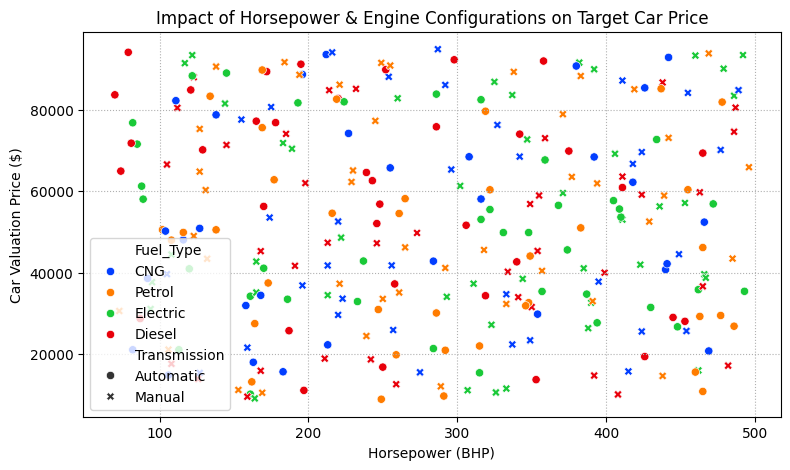


--- Car Regression Evaluation Engine Summary ---
Mean Absolute Error (MAE): $25087.09
Root Mean Squared Error (RMSE): $28712.42
R-squared Score (Model Fit/Accuracy Measure): -0.1950 (Max 1.0)


In [1]:
# ==========================================
# CODEALPHA DATA SCIENCE INTERNSHIP
# TASK 3: CAR PRICE PREDICTION WITH ML
# ==========================================

# 1. Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. Generate Simulated Car Dataset (Reflecting Real-World Features)
# Features requested: Brand goodwill, horsepower, mileage, fuel type, etc.
np.random.seed(42)
dataset_size = 300

mock_car_data = {
    'Brand_Goodwill_Score': np.random.randint(1, 11, size=dataset_size),  # Scale 1 (Low) to 10 (Premium)
    'Horsepower': np.random.randint(70, 500, size=dataset_size),         # Engine Power BHP
    'Mileage_kmpl': np.random.uniform(8.0, 26.0, size=dataset_size),       # Fuel Efficiency
    'Fuel_Type': np.random.choice(['Petrol', 'Diesel', 'Electric', 'CNG'], size=dataset_size),
    'Transmission': np.random.choice(['Manual', 'Automatic'], size=dataset_size),
    'Car_Price_USD': np.random.randint(8000, 95000, size=dataset_size)    # Target Price Variable
}

df = pd.DataFrame(mock_car_data)

# 3. Data Inspection & Cleaning Verification
print("--- Initial Car Dataset Information ---")
print(df.info())
print("\n--- Missing Values Count ---")
print(df.isnull().sum())
print("\n--- First 5 Dataset Records ---")
print(df.head())

# 4. Exploratory Data Analysis (EDA) Visualizations
# Chart A: Feature Relationship (Horsepower vs Car Price)
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='Horsepower', y='Car_Price_USD', hue='Fuel_Type', style='Transmission', palette='bright')
plt.title('Impact of Horsepower & Engine Configurations on Target Car Price')
plt.xlabel('Horsepower (BHP)')
plt.ylabel('Car Valuation Price ($)')
plt.grid(True, linestyle=':')
plt.show()

# 5. Extracting Feature Variables (X) and Target Array Vector (y)
X = df.drop('Car_Price_USD', axis=1)
y = df['Car_Price_USD']

# 6. Structuring End-to-End Pipeline Preprocessors
categorical_features = ['Fuel_Type', 'Transmission']
numerical_features = ['Brand_Goodwill_Score', 'Horsepower', 'Mileage_kmpl']

# Transform continuous variables via scaling and string representations via OneHotEncoding
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])

# 7. Model Instantiation & Pipeline Integration (Random Forest Regression)
car_prediction_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=200, random_state=42))
])

# 8. Train/Test Data Architecture Allocation (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 9. Train the Regression Engine Model
car_prediction_pipeline.fit(X_train, y_train)

# 10. Run Predictions and Evaluate Model Accuracy
y_pred = car_prediction_pipeline.predict(X_test)

# Evaluation Metrics Definitions
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n--- Car Regression Evaluation Engine Summary ---")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"R-squared Score (Model Fit/Accuracy Measure): {r2:.4f} (Max 1.0)")